In [219]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Input,Flatten,Dense,Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping 

# Loading of dataset

In [220]:
breast_cancer_dataset=sklearn.datasets.load_breast_cancer()
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]]), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
 

In [221]:
# Creating dataframe of the above dataset 
breast_df=pd.DataFrame(breast_cancer_dataset.data,columns=breast_cancer_dataset.feature_names)
print(breast_df)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [222]:
# adding target column to the dataframe
breast_df["label"]=breast_cancer_dataset.target
print(breast_df)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

# Basic EDA

In [223]:
breast_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [224]:
breast_df.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [225]:
breast_df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [226]:
breast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [227]:
breast_df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
564    False
565    False
566    False
567    False
568    False
Length: 569, dtype: bool

In [228]:
breast_df.duplicated().sum()

np.int64(0)

In [229]:
breast_df.isna()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
565,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
566,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
567,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [230]:
breast_df.isna().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
label                      0
dtype: int64

In [231]:
# Checking The distribution of target variable 
breast_df["label"].value_counts()

label
1    357
0    212
Name: count, dtype: int64

# label 0-> Malignant
# label 1-> Benign

In [232]:
# Calculating mean based on the label 
# This shows that the value of evey column for malignant is very high as compared to values for benign.
# This also shows that the column has high co-variance so they require feature scaling in further preprocessing.
breast_df.groupby("label").mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
label,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


In [233]:
# Representing co-relation label wise
for label_val,group in breast_df.groupby("label"):
    print(f"{label_val}")
    print(group.corr())

0
                         mean radius  mean texture  mean perimeter  mean area  \
mean radius                 1.000000      0.106516        0.995281   0.990078   
mean texture                0.106516      1.000000        0.110682   0.103729   
mean perimeter              0.995281      0.110682        1.000000   0.987223   
mean area                   0.990078      0.103729        0.987223   1.000000   
mean smoothness            -0.116036     -0.143920       -0.052401  -0.088281   
mean compactness            0.169168      0.032567        0.256409   0.170181   
mean concavity              0.482750      0.067135        0.554994   0.493151   
mean concave points         0.675519      0.017453        0.730158   0.677513   
mean symmetry              -0.076442     -0.090009       -0.014329  -0.080828   
mean fractal dimension     -0.388679     -0.061559       -0.313563  -0.368612   
radius error                0.639270      0.038681        0.654083   0.685765   
texture error             

In [234]:
# Representing co-relation with respect to label 
for col in breast_df.columns:
    if col != "label":
        print(col,breast_df[col].corr(breast_df["label"]))


mean radius -0.7300285113754558
mean texture -0.4151852998452037
mean perimeter -0.742635529725832
mean area -0.7089838365853891
mean smoothness -0.3585599650859316
mean compactness -0.5965336775082525
mean concavity -0.6963597071719048
mean concave points -0.7766138400204349
mean symmetry -0.33049855426254654
mean fractal dimension 0.012837602698432366
radius error -0.5671338208247165
texture error 0.008303332973877427
perimeter error -0.5561407034314825
area error -0.5482359402780237
smoothness error 0.06701601057948728
compactness error -0.29299924424885804
concavity error -0.25372976598083014
concave points error -0.40804233271650414
symmetry error 0.0065217558706479615
fractal dimension error -0.07797241739025601
worst radius -0.7764537785950386
worst texture -0.45690282139679755
worst perimeter -0.7829141371737584
worst area -0.7338250349210504
worst smoothness -0.421464861066402
worst compactness -0.5909982378417914
worst concavity -0.6596102103692325
worst concave points -0.793

In [235]:
# Representing covariance with respect to label 
for col in breast_df.columns:
    if col != "label":
        print(col,breast_df[col].cov(breast_df["label"]))


mean radius -1.2449544914478086
mean texture -0.8641452758731648
mean perimeter -8.732438241045571
mean area -120.73822186192729
mean smoothness -0.002440317582118369
mean compactness -0.015245636185301616
mean concavity -0.026864058180895566
mean concave points -0.01458278358375208
mean symmetry -0.004384480742097575
mean fractal dimension 4.386141983712459e-05
radius error -0.07610743675586025
texture error 0.0022165960172281533
perimeter error -0.5441345843956534
area error -12.06881907349192
smoothness error 9.737241020817353e-05
compactness error -0.002539157686452636
concavity error -0.0037063769981930256
concave points error -0.001218378412832001
symmetry error 2.6088625337260897e-05
fractal dimension error -9.98422188668036e-05
worst radius -1.816041832718632
worst texture -1.3589589470036385
worst perimeter -12.730867812322089
worst area -202.18499436867262
worst smoothness -0.004656774765464491
worst compactness -0.04499739557291023
worst concavity -0.06659229144285755
worst 

# Visualizing the co-relation

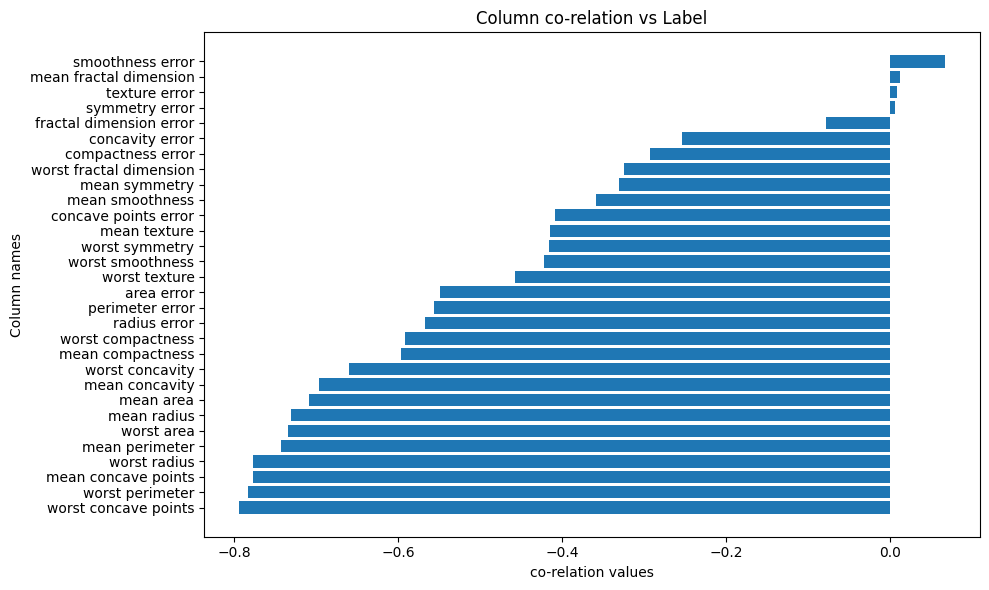

In [236]:
# Plotting graph for co-realtion with respect to label so that we can understand that how labels are dependent on features.
# from below bar graph we can see that some of the columns have not much impact on the prediction.
# As a result, we can drop it from our dataframe.
plt.figure(figsize=(10,6))
cor=[]
corrs=[]
for col in breast_df.columns:
    if col != "label":
        cor.append(col)
        corrs.append(breast_df[col].corr(breast_df["label"]))

# sorted pair 
sorted_pair=sorted(zip(corrs,cor))
corrs_sorted,cor_sorted=zip(*sorted_pair)
plt.barh(cor_sorted,corrs_sorted)
plt.xlabel("co-relation values")
plt.ylabel("Column names")
plt.title("Column co-relation vs Label")
plt.tight_layout()
plt.show()

# 1.From above  we can see that column name(mean fractal dimension,texture error,smoothness error,symmetry error,fractal dimension error) has very small co-relation(0-0.1).
# 2.As a reult, we can delete this columns from our dataframe because they did not impact on the label. 

# Preprocessing of the data 

# 1.Feature extraction

In [237]:
breast_df=breast_df.drop(columns=["mean fractal dimension","texture error","smoothness error","symmetry error","fractal dimension error"])
breast_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,1.0950,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.5435,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.7456,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.4956,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.7572,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,1.1760,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.7655,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.4564,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.7260,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


# 2.Seperating features and labels for dataframe

In [238]:
labels=breast_df["label"]
labels

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: label, Length: 569, dtype: int64

In [239]:
features=breast_df.drop(columns=["label"],axis=1)
features

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,1.0950,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.5435,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.7456,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.4956,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.7572,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,1.1760,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.7655,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.4564,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.7260,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


# 3.Feature Scaling

In [240]:
# As we can say that the values in every column is varying a lot.
# So,This will affect our model training and its prediction.
# As a result, our model's performance gets reduced.
# So for better prediction and model training , we require feature scaling
# Feature Scaling is a critical preprocessing technique used in machine learning to transform numerical values into common and consistent scale.
# For feature Scaling , we can use either MinMaxScalar or StandandardScalar

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)

In [241]:
scaled_features

array([[ 1.09706398, -2.07333501,  1.26993369, ...,  2.29607613,
         2.75062224,  1.93701461],
       [ 1.82982061, -0.35363241,  1.68595471, ...,  1.0870843 ,
        -0.24388967,  0.28118999],
       [ 1.57988811,  0.45618695,  1.56650313, ...,  1.95500035,
         1.152255  ,  0.20139121],
       ...,
       [ 0.70228425,  2.0455738 ,  0.67267578, ...,  0.41406869,
        -1.10454895, -0.31840916],
       [ 1.83834103,  2.33645719,  1.98252415, ...,  2.28998549,
         1.91908301,  2.21963528],
       [-1.80840125,  1.22179204, -1.81438851, ..., -1.74506282,
        -0.04813821, -0.75120669]])

In [242]:
# converting to dataframe
scaled_features_df=pd.DataFrame(scaled_features,columns=features.columns,index=features.index)
scaled_features_df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,radius error,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.489734,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,0.499255,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,1.228676,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,0.326373,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,1.270543,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,2.782080,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,1.300499,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,0.184892,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.157935,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


# Now I will use this Scaled_features_df for further train_test_split

# Train_Test_Split

In [243]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(scaled_features_df,labels,test_size=0.2,random_state=42)

In [244]:
# shape of x_train and y_train
print(x_train.shape,y_train.shape)

(455, 25) (455,)


In [245]:
# shape of x_test and y_test
print(x_test.shape,y_test.shape)

(114, 25) (114,)


# Building a Artifical Neural Network

In [246]:
model1=Sequential()
model1.add(Input(shape=(25,)))
model1.add(Flatten())

model1.add(Dense(
    20,
    activation="relu",
    kernel_regularizer=l2(0.0001)
))
model1.add(Dense(
    20,
    activation="relu",
    kernel_regularizer=l2(0.0001)
))
model1.add(Dense(
    2,
    activation="softmax"
))

In [247]:
model2=Sequential()
model2.add(Input(shape=(25,)))
model2.add(Flatten())

model2.add(Dense(
    20,
    activation="sigmoid",
    kernel_regularizer=l2(0.0001)
))
model2.add(Dense(
    20,
    activation="sigmoid",
    kernel_regularizer=l2(0.0001)
))
model2.add(Dense(
    2,
    activation="softmax"
))

In [248]:
model3=Sequential()
model3.add(Input(shape=(25,)))
model3.add(Flatten())

model3.add(Dense(
    16,
    activation="relu",
))
model3.add(Dense(
    16,
    activation="relu",
))
model3.add(Dense(
    2,
    activation="softmax"
))

In [249]:
model4=Sequential()
model4.add(Input(shape=(25,)))
model4.add(Flatten())

model4.add(Dense(
    16,
    activation="sigmoid",
))
model4.add(Dense(
    16,
    activation="sigmoid",
))
model4.add(Dense(
    2,
    activation="softmax"
))

# Compilation of model

In [250]:
Seed=42
tf.random.set_seed(Seed)
model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [251]:
Seed=42
tf.random.set_seed(Seed)
model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [252]:
Seed=42
tf.random.set_seed(Seed)
model3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [253]:
Seed=42
tf.random.set_seed(Seed)
model4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Training of neural network

In [254]:
early_stopping=EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)
hist_model1=model1.fit(x_train,y_train,epochs=15,batch_size=32,verbose=1,validation_split=0.1,callbacks=[early_stopping])

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6724 - loss: 0.6246 - val_accuracy: 0.8696 - val_loss: 0.5091
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9071 - loss: 0.4345 - val_accuracy: 0.8696 - val_loss: 0.3786
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9291 - loss: 0.3229 - val_accuracy: 0.8696 - val_loss: 0.2981
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9364 - loss: 0.2549 - val_accuracy: 0.8913 - val_loss: 0.2504
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9364 - loss: 0.2117 - val_accuracy: 0.8913 - val_loss: 0.2205
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9389 - loss: 0.1819 - val_accuracy: 0.8913 - val_loss: 0.1993
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9487 - loss: 0.1592 - val_accuracy: 0.8913 - val_loss: 0.1829
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9535 - loss: 0.1405 - val_accuracy: 0.9130 - val_loss

In [255]:
early_stopping=EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True)
hist_model2=model2.fit(x_train,y_train,epochs=15,batch_size=32,verbose=1,validation_split=0.1,callbacks=[early_stopping])

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6210 - loss: 0.6964 - val_accuracy: 0.6957 - val_loss: 0.6357
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6210 - loss: 0.6549 - val_accuracy: 0.6957 - val_loss: 0.5984
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6210 - loss: 0.6224 - val_accuracy: 0.6957 - val_loss: 0.5684
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6210 - loss: 0.5910 - val_accuracy: 0.6957 - val_loss: 0.5384
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6479 - loss: 0.5578 - val_accuracy: 0.7609 - val_loss: 0.5057
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7531 - loss: 0.5215 - val_accuracy: 0.8261 - val_loss: 0.4703
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8631 - loss: 0.4826 - val_accuracy: 0.8696 - val_loss: 0.4333
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8998 - loss: 0.4424 - val_accuracy: 0.8913 - val_loss

In [256]:
hist_model3=model3.fit(x_train,y_train,epochs=15,batch_size=32,verbose=1,validation_split=0.1)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5281 - loss: 0.6374 - val_accuracy: 0.7609 - val_loss: 0.5954
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8215 - loss: 0.5279 - val_accuracy: 0.8696 - val_loss: 0.4967
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9144 - loss: 0.4422 - val_accuracy: 0.9130 - val_loss: 0.4098
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9364 - loss: 0.3701 - val_accuracy: 0.9348 - val_loss: 0.3318
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9389 - loss: 0.3070 - val_accuracy: 0.9348 - val_loss: 0.2674
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9535 - loss: 0.2532 - val_accuracy: 0.9565 - val_loss: 0.2176
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9535 - loss: 0.2112 - val_accuracy: 0.9783 - val_loss: 0.1820
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9584 - loss: 0.1798 - val_accuracy: 0.9783 - val_loss

In [257]:
hist_model4=model4.fit(x_train,y_train,epochs=15,batch_size=32,verbose=1,validation_split=0.1)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3790 - loss: 0.8398 - val_accuracy: 0.3043 - val_loss: 0.8029
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3790 - loss: 0.7266 - val_accuracy: 0.3043 - val_loss: 0.6883
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6870 - loss: 0.6499 - val_accuracy: 0.9348 - val_loss: 0.6119
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8826 - loss: 0.5996 - val_accuracy: 0.8478 - val_loss: 0.5615
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8313 - loss: 0.5637 - val_accuracy: 0.8478 - val_loss: 0.5253
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8166 - loss: 0.5337 - val_accuracy: 0.8478 - val_loss: 0.4956
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8557 - loss: 0.5051 - val_accuracy: 0.8696 - val_loss: 0.4684
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8924 - loss: 0.4765 - val_accuracy: 0.8696 - val_loss

# Training Accuracy of all models

In [258]:
# hist_model.history["accuracy"]  will return a list of accuracy per epoch
print("Training Accuracy\n")
train_acc={
    "model1":round(hist_model1.history["accuracy"][-1],4),
    "model2":round(hist_model2.history["accuracy"][-1],4),
    "model3":round(hist_model3.history["accuracy"][-1],4),
    "model4":round(hist_model4.history["accuracy"][-1],4)
}
for name,accuracy in train_acc.items():
    print(f"{name}:{accuracy}")

Training Accuracy

model1:0.978
model2:0.9389
model3:0.9804
model4:0.9389


# Training Loss of all models

In [259]:
print("Training Loss\n")
train_loss={
    "model1":hist_model1.history["loss"][-1],
    "model2":hist_model2.history["loss"][-1],
    "model3":hist_model3.history["loss"][-1],
    "model4":hist_model4.history["loss"][-1]
}
for name,loss in train_loss.items():
    print(f"{name}: {loss}")

Training Loss

model1: 0.0778578519821167
model2: 0.2235632836818695
model3: 0.08696481585502625
model4: 0.29044315218925476


# Validation Accuracy of all models

In [260]:
print("Validation Accuracy\n")
val_acc={
    "model1":round(hist_model1.history["val_accuracy"][-1],4),
    "model2":round(hist_model2.history["val_accuracy"][-1],4),
    "model3":round(hist_model3.history["val_accuracy"][-1],4),
    "model4":round(hist_model4.history["val_accuracy"][-1],4)
}
for name,accuracy in val_acc.items():
    print(f"{name}:{accuracy}")

Validation Accuracy

model1:0.913
model2:0.9348
model3:0.9783
model4:0.913


# Validation loss of all models

In [261]:
print("Validation Loss\n")
validate_loss={
    "model1":hist_model1.history["val_loss"][-1],
    "model2":hist_model2.history["val_loss"][-1],
    "model3":hist_model3.history["val_loss"][-1],
    "model4":hist_model4.history["val_loss"][-1]
}
for name,loss in validate_loss.items():
    print(f"{name}: {loss}")

Validation Loss

model1: 0.13305403292179108
model2: 0.206503763794899
model3: 0.10478854924440384
model4: 0.2833552956581116


# Testing of all models

In [262]:
test_model1=model1.evaluate(x_test,y_test,verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9561 - loss: 0.0760 


In [263]:
test_model2=model2.evaluate(x_test,y_test,verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.1831 


In [264]:
test_model3=model3.evaluate(x_test,y_test,verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9561 - loss: 0.0921 


In [265]:
test_model4=model4.evaluate(x_test,y_test,verbose=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9649 - loss: 0.2623 


In [266]:
print("Testing Accuracy\n")
test_acc={
    "model1":round(test_model1[1],4),
    "model2":round(test_model2[1],4),
    "model3":round(test_model3[1],4),
    "model4":round(test_model4[1],4)
}
for name,accuracy in test_acc.items():
    print(f"{name}:{accuracy}")

Testing Accuracy

model1:0.9561
model2:0.9649
model3:0.9561
model4:0.9649


In [267]:
test=[
    round(test_model1[1],4),
    round(test_model2[1],4),
    round(test_model3[1],4),
    round(test_model4[1],4)
]
print(test)

[0.9561, 0.9649, 0.9561, 0.9649]


In [268]:
print("Total number of parameters used by each model\n")
parameter={
    "model1":model1.count_params(),
    "model2":model2.count_params(),
    "model3":model3.count_params(),
    "model4":model4.count_params(),
}
for name,para in parameter.items():
    print(f"{name}:{para}")

Total number of parameters used by each model

model1:982
model2:982
model3:722
model4:722


# Calculating Generation Gap

In [269]:
# Generation gap is the difference between training accuracy and validation accuracy 
models=[
    "model1",
    "model2",
    "model3",
    "model4"
]


train=[
    round(hist_model1.history["accuracy"][-1],4),
    round(hist_model2.history["accuracy"][-1],4),
    round(hist_model3.history["accuracy"][-1],4),
    round(hist_model4.history["accuracy"][-1],4)
]
validate=[
    round(hist_model1.history["val_accuracy"][-1],4),
    round(hist_model2.history["val_accuracy"][-1],4),
    round(hist_model3.history["val_accuracy"][-1],4),
    round(hist_model4.history["val_accuracy"][-1],4)
]
parameters=[
    model1.count_params(),
    model2.count_params(),
    model3.count_params(),
    model4.count_params()
]
generation_gap=[round(train[i]-validate[i],3) for i in range(len(models))]
print(generation_gap)

[0.065, 0.004, 0.002, 0.026]


# Comparison Matrix

In [270]:
# creating comparison matrix
comp_mat=pd.DataFrame({
    "Models":models,
    "Training Accuracy":train,
    "Validation Accuracy":validate,
    "Generation Gap":generation_gap,
    "Total Parameters":parameters
})
print(comp_mat.set_index("Models"))

        Training Accuracy  Validation Accuracy  Generation Gap  \
Models                                                           
model1             0.9780               0.9130           0.065   
model2             0.9389               0.9348           0.004   
model3             0.9804               0.9783           0.002   
model4             0.9389               0.9130           0.026   

        Total Parameters  
Models                    
model1               982  
model2               982  
model3               722  
model4               722  


# Visualizing training and validation accuracy per epoch 

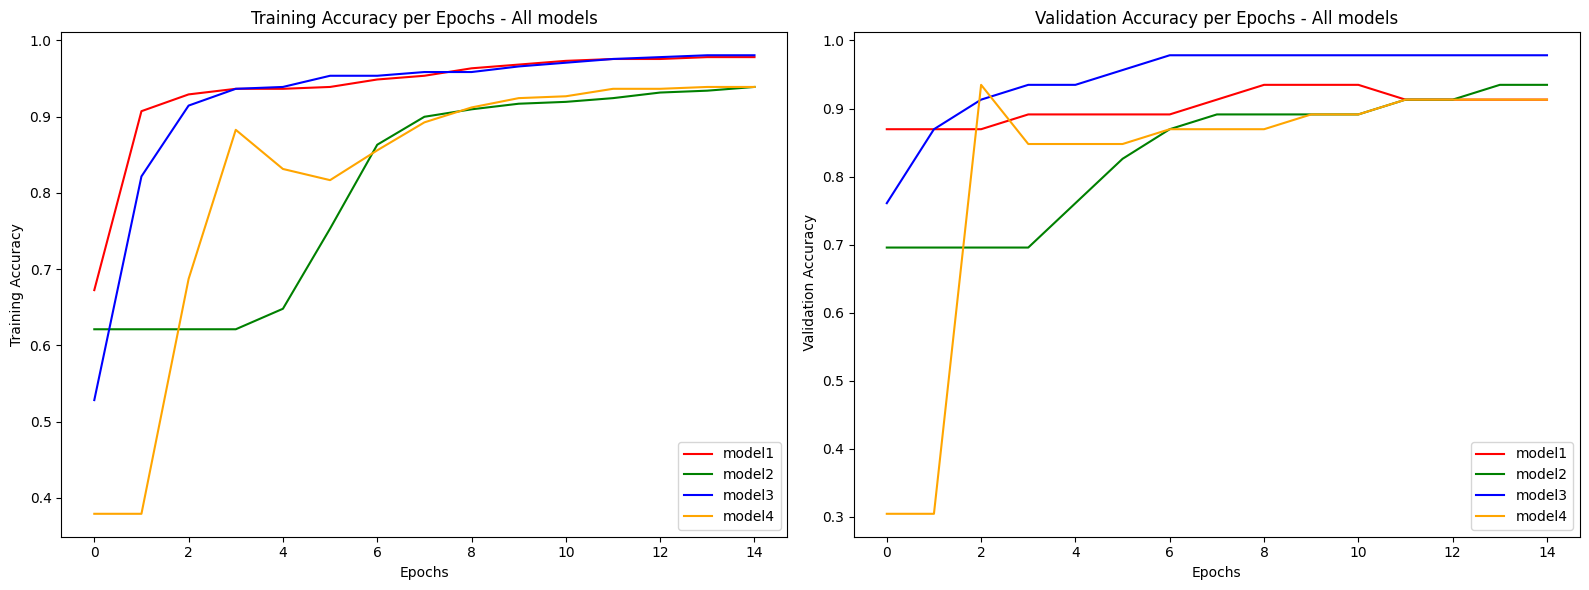

In [271]:
# Visualizing training and validation accuracy per epoch 
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)

colors = ["red", "green", "blue", "orange"]
plt.plot(hist_model1.history["accuracy"],label="model1",color=colors[0])
plt.plot(hist_model2.history["accuracy"],label="model2",color=colors[1])
plt.plot(hist_model3.history["accuracy"],label="model3",color=colors[2])
plt.plot(hist_model4.history["accuracy"],label="model4",color=colors[3])
plt.ylabel("Training Accuracy")
plt.xlabel("Epochs")
plt.title("Training Accuracy per Epochs - All models")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist_model1.history["val_accuracy"],label="model1",color=colors[0])
plt.plot(hist_model2.history["val_accuracy"],label="model2",color=colors[1])
plt.plot(hist_model3.history["val_accuracy"],label="model3",color=colors[2])
plt.plot(hist_model4.history["val_accuracy"],label="model4",color=colors[3])
plt.ylabel(" Validation Accuracy")
plt.xlabel("Epochs")
plt.title("Validation Accuracy per Epochs - All models")
plt.legend()

plt.tight_layout()
plt.show()

# Visualizing Testing Accuracy and Gneration Gap per model

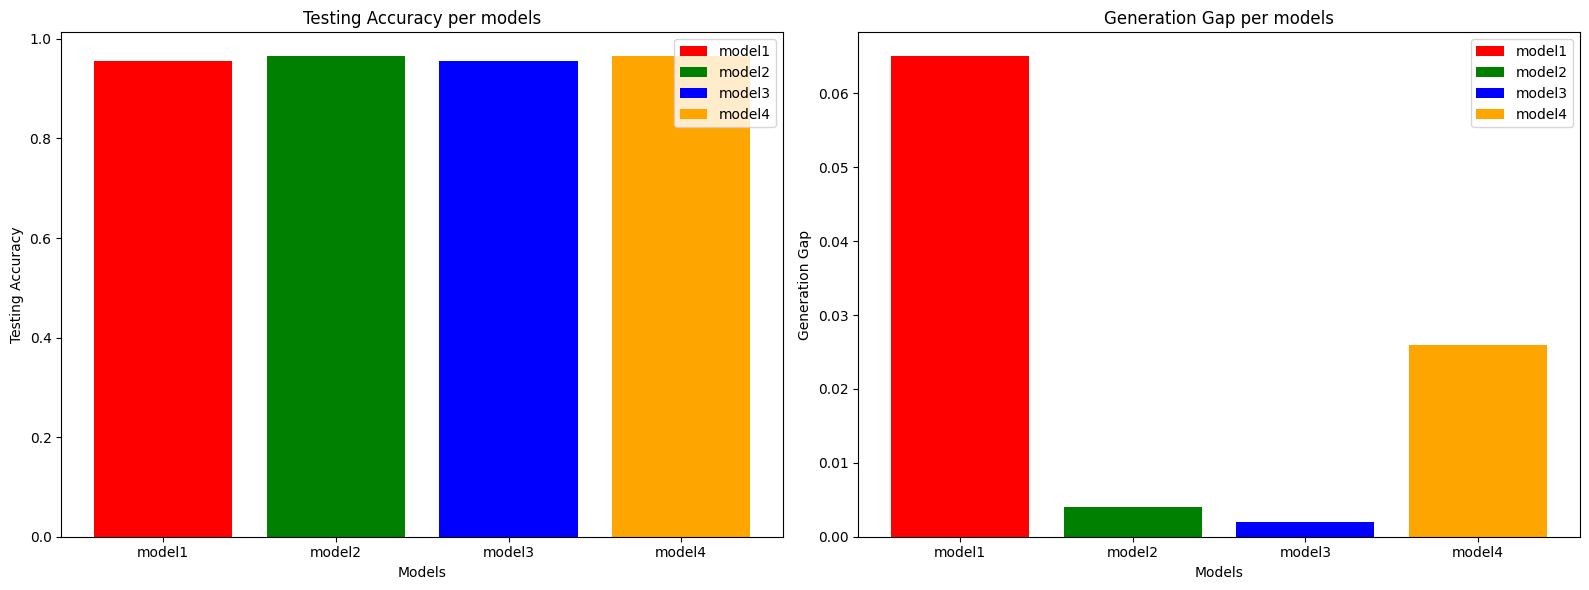

In [272]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)

colors = ["red", "green", "blue", "orange"]
bars=plt.bar(models,test,color=colors)
plt.ylabel("Testing Accuracy")
plt.xlabel("Models")
plt.title("Testing Accuracy per models")
plt.legend(bars,models)

plt.subplot(1,2,2)

colors = ["red", "green", "blue", "orange"]
bar=plt.bar(models,generation_gap,color=colors)
plt.ylabel("Generation Gap")
plt.xlabel("Models")
plt.title("Generation Gap per models")
plt.legend(bar,models)
plt.tight_layout()
plt.show()

# Prediction for best model (model3)

In [274]:
y_pred=model3.predict(x_test)
print(y_pred)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[1.11097306e-01 8.88902664e-01]
 [9.99757290e-01 2.42685011e-04]
 [9.41257417e-01 5.87425753e-02]
 [3.56227607e-02 9.64377165e-01]
 [1.03121055e-02 9.89687860e-01]
 [9.99999821e-01 7.24211517e-08]
 [9.99998868e-01 1.03626735e-06]
 [9.62325454e-01 3.76744792e-02]
 [5.65123975e-01 4.34875935e-01]
 [4.26210649e-03 9.95737910e-01]
 [4.36912738e-02 9.56308603e-01]
 [9.51995671e-01 4.80042696e-02]
 [1.50989126e-02 9.84901071e-01]
 [9.13666964e-01 8.63330290e-02]
 [3.77609325e-03 9.96223867e-01]
 [9.98482943e-01 1.51696231e-03]
 [5.89967007e-03 9.94100273e-01]
 [8.93137010e-04 9.99106765e-01]
 [1.98401278e-04 9.99801636e-01]
 [9.99918044e-01 8.18484186e-05]
 [1.44259766e-01 8.55740130e-01]
 [2.83653811e-02 9.71634567e-01]
 [9.99998629e-01 1.32766513e-06]
 [8.60159344e-04 9.99139786e-01]
 [8.29744246e-03 9.91702557e-01]
 [9.75085050e-03 9.90249217e-01]
 [1.04859332e-02 9.89513934e-01]
 [5.52287251e-02 9.44771290e-01]
 [1.39318174e-02 9.86068010e-01]
 [9.9

In [275]:
print(y_pred.shape)

(114, 2)


In [276]:
print(y_pred[0])

[0.11109731 0.88890266]


# Converting the prediction probabilities into labels

In [277]:
y_pred_labels=[np.argmax(i) for i in y_pred]
print(y_pred_labels)

[np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1)

# Confusion matrix

In [280]:
# y_test-> true labels
# y_pred_labels-> predicted labels
from tensorflow.math import confusion_matrix
cm=confusion_matrix(y_test,y_pred_labels)
print(cm)

tf.Tensor(
[[41  2]
 [ 3 68]], shape=(2, 2), dtype=int32)


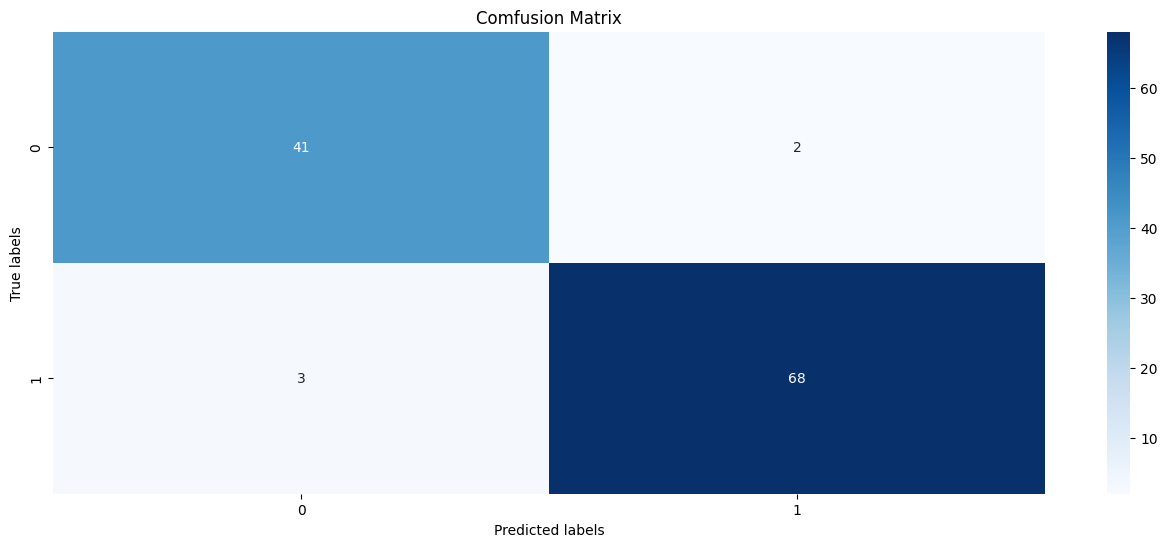

In [282]:
plt.figure(figsize=(16,6))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted labels")
plt.ylabel("True labels")
plt.title("Comfusion Matrix")
plt.show()

# Building Predictive System

In [285]:
input_data=(17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,1.095,8.589,153.4,0.006399,0.05373,0.01587,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
)
# converting input_data into numpy array
input_data_as_numpy_array=np.asarray(input_data)
# reshape numpy array as we are predicting for single data point
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)
# n the input_data
input_data_std=scaler.transform(input_data_reshaped)

prediction=model3.predict(input_data_std)
print(prediction)

prediction_label=[np.argmax(prediction)]
print(prediction_label)

if prediction_label[0]==0:
    print("The Brain Tumor is Malignant")
else:
    print("The Brain Tumor is Benign")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[9.9999928e-01 6.9484395e-07]]
[np.int64(0)]
The Brain Tumor is Malignant


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Saving the best model : model3

In [299]:
model3.save("model3.keras")